In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("music_streams.csv")

In [3]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [4]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [5]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram

### Monthly Streams

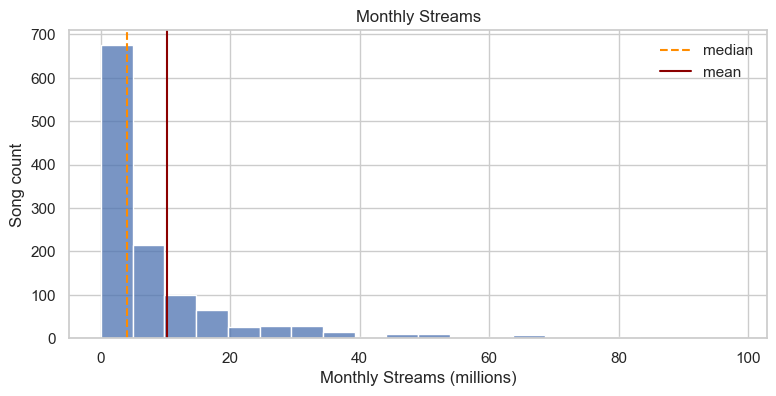

In [8]:
fig, ax = plt.subplots(figsize=(9,4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()
sns.histplot(data=df[df.streams_millions < 100], x="streams_millions", bins=20, ax=ax)
ax.axvline(median, color="darkorange", linestyle="--", label = "median")
ax.axvline(mean, color="darkred", label = "mean")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Streams (millions)")
ax.set_ylabel("Song count")
ax.set_title("Monthly Streams")
plt.show()

### Monthly Listeners

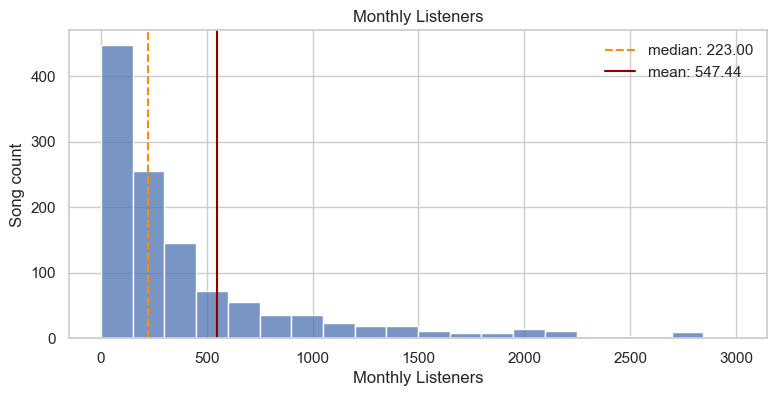

In [10]:
fig, ax = plt.subplots(figsize=(9,4))
median = df.monthly_listeners.median()
mean = df.monthly_listeners.mean()
sns.histplot(data=df[df.monthly_listeners < 3000], x="monthly_listeners", bins=20, ax=ax)
ax.axvline(median, color="darkorange", linestyle="--", label = f"median: {median:.2f}")
ax.axvline(mean, color="darkred", label = f"mean: {mean:.2f}")
ax.legend(frameon=False)
ax.set_xlabel("Monthly Listeners")
ax.set_ylabel("Song count")
ax.set_title("Monthly Listeners")
plt.show()

## Boxplots

### Energy Boxplot

In [13]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

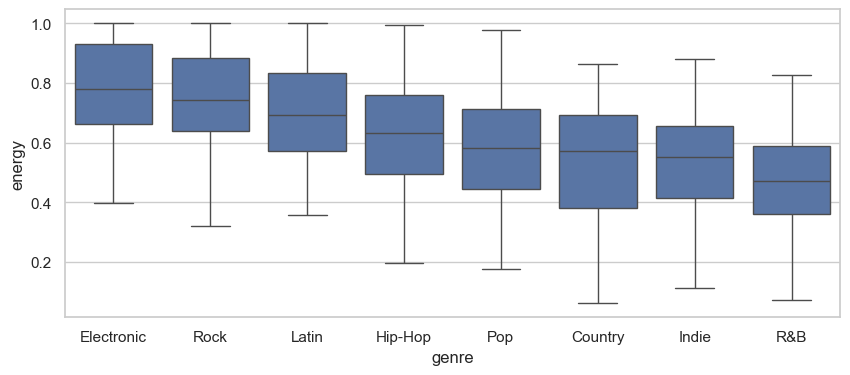

In [14]:
fig, ax = plt.subplots(figsize=(10,4))
sns.boxplot(data=df,y="energy", x="genre",order=order, ax = ax)

In [15]:
order = df.groupby("key")["loudness_db"].median().sort_values(ascending=False).index
order

Index(['A# Minor', 'C# Major', 'B Minor', 'F# Minor', 'E Major', 'D# Major',
       'G Minor', 'B Major', 'D# Minor', 'C Minor', 'E Minor', 'A Minor',
       'G# Minor', 'C# Minor', 'F# Major', 'F Major', 'D Minor', 'G# Major',
       'F Minor', 'C Major', 'G Major', 'A# Major', 'A Major', 'D Major'],
      dtype='object', name='key')

<Axes: xlabel='key', ylabel='loudness_db'>

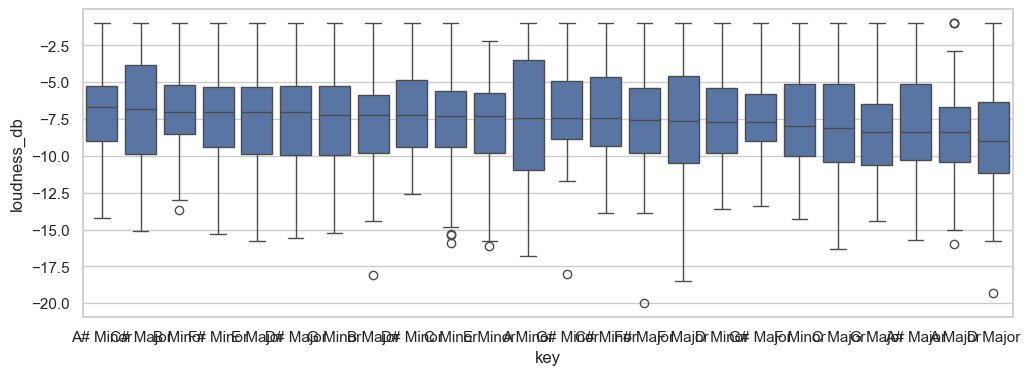

In [16]:
fig, ax = plt.subplots(figsize=(12,4))
sns.boxplot(data=df,y="loudness_db", x="key",order=order, ax = ax)

## Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

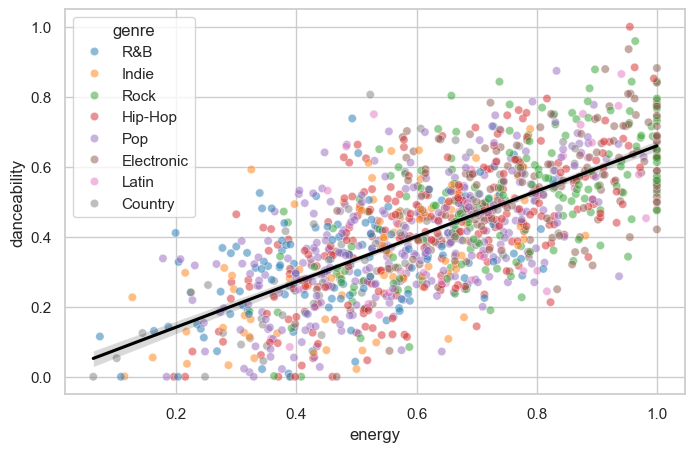

In [18]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x='energy', y='danceability', color='grey', alpha=0.5, hue="genre", palette="tab10")
sns.regplot(data=df, x="energy", y="danceability", scatter=False, color="black")

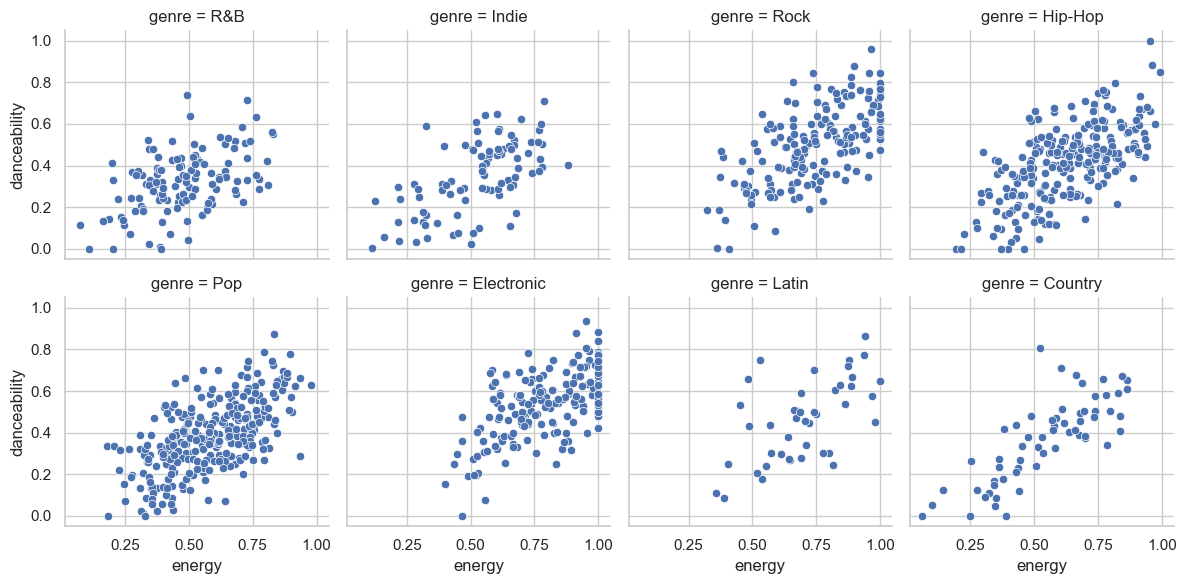

In [19]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy", "danceability")

<Axes: xlabel='streams_millions', ylabel='monthly_listeners'>

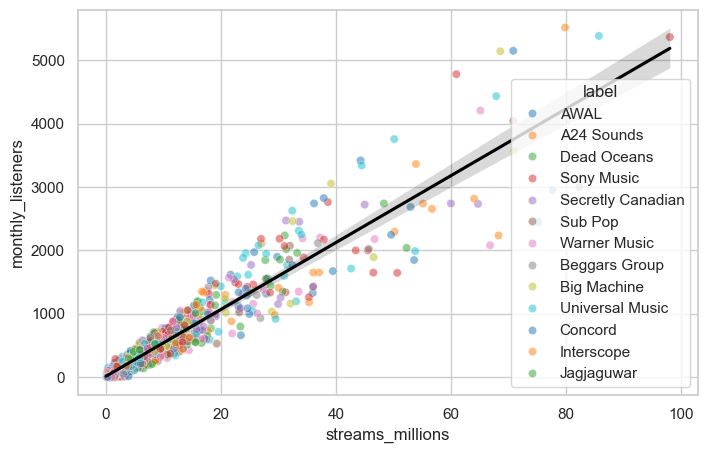

In [20]:
sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df[df.streams_millions < 100], x='streams_millions', y='monthly_listeners', color='grey', alpha=0.5, hue="label", palette="tab10")
sns.regplot(data=df[df.streams_millions < 100], x="streams_millions", y="monthly_listeners", scatter=False, color="black")

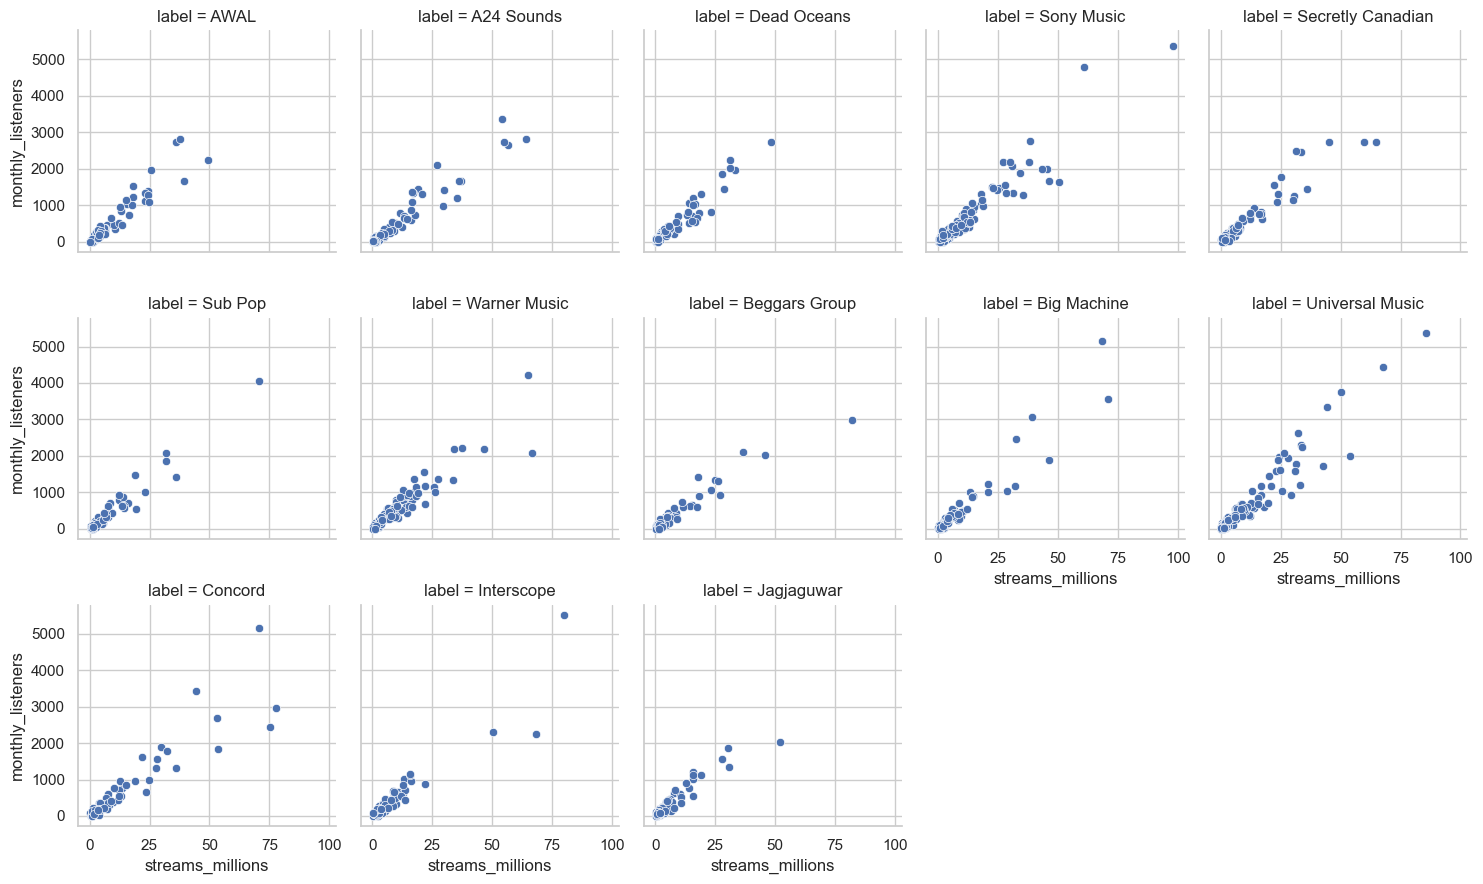

In [21]:
g = sns.FacetGrid(df[df.streams_millions < 100], col="label", col_wrap=5)
g.map(sns.scatterplot, "streams_millions", "monthly_listeners")

## Line Charts

In [23]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016],
      dtype=int64)

In [24]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

year
2015     7.160
2016     3.540
2017     3.560
2018    11.370
2019     4.720
2020     5.075
2021     3.645
2022     4.445
2023     4.230
2024     3.390
Name: streams_millions, dtype: float64

    year       genre  streams_millions
0   2015  Electronic             6.040
1   2015     Hip-Hop             5.755
2   2015       Indie            13.900
3   2015         Pop             7.160
4   2015         R&B             3.590
..   ...         ...               ...
63  2024       Indie             3.420
64  2024       Latin             3.800
65  2024         Pop             3.390
66  2024         R&B             3.730
67  2024        Rock             4.115

[68 rows x 3 columns]


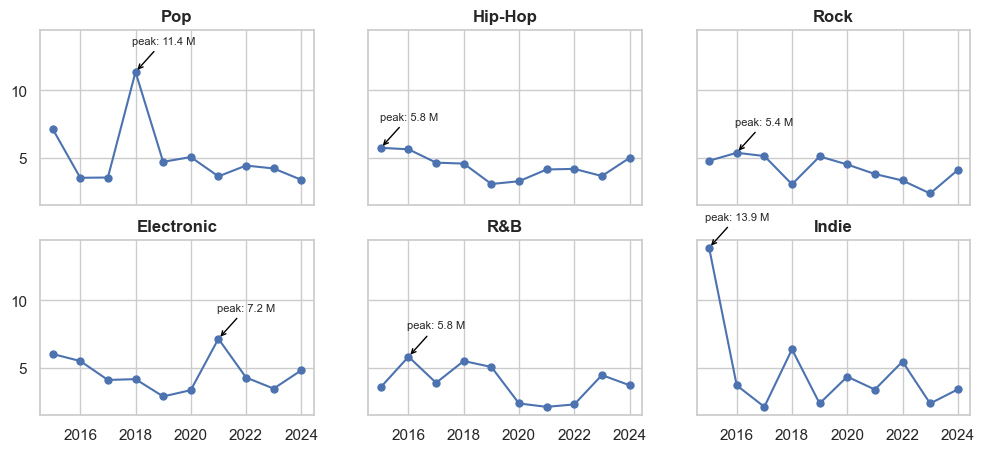

In [25]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie", "Latin"]

trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

print(trend)

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
    subD = trend[trend.genre == genre]
    ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
    peak = subD.loc[subD.streams_millions.idxmax()]
    ax.annotate(f"peak: {peak.streams_millions:.1f} M", xy=(peak.year, peak.streams_millions), xytext=(20, 20), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="black", lw=1), ha="center", fontsize=8)
    ax.set_title(genre, fontweight="bold")

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(pop_trend.index, pop_trend)

In [26]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [27]:
df.label.unique()

array(['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope',
       'Jagjaguwar'], dtype=object)

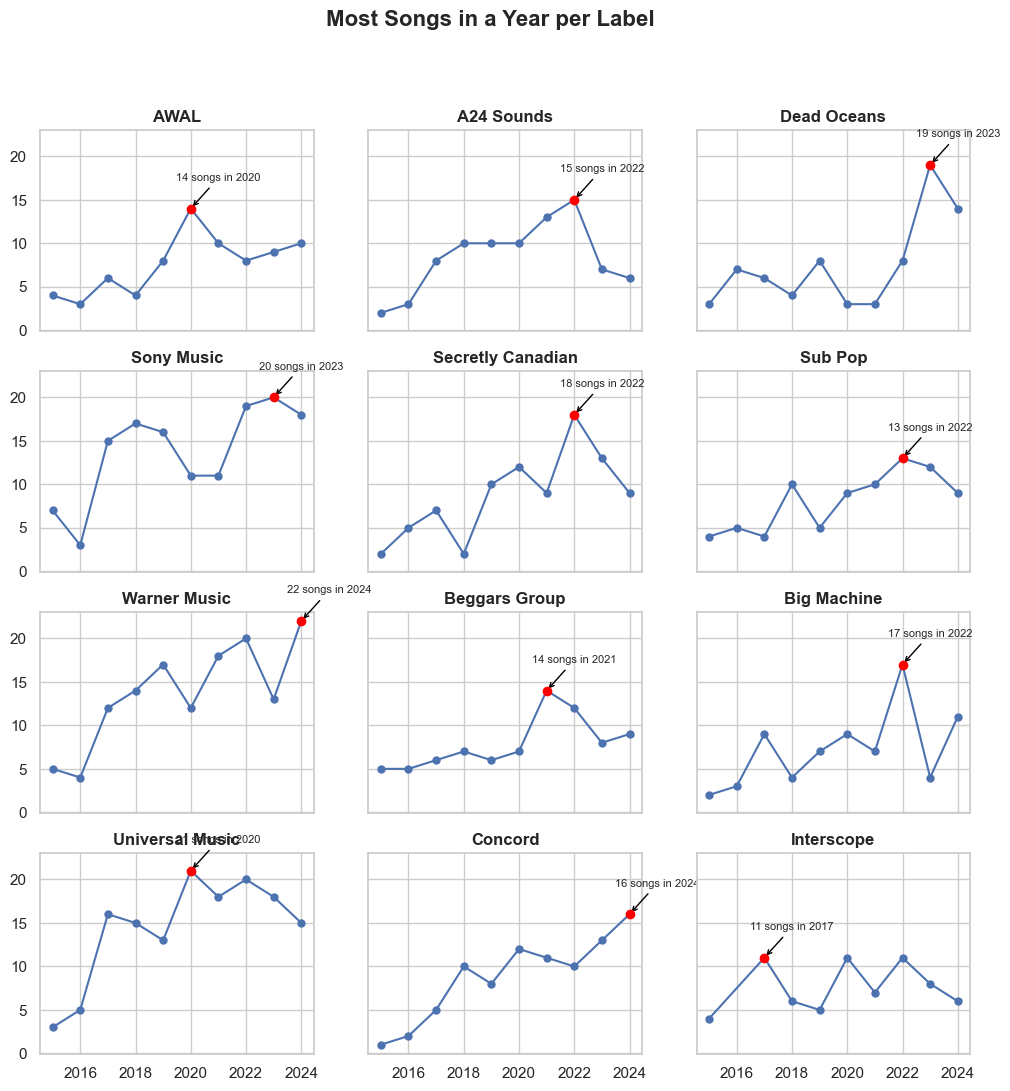

In [28]:
labels = ['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope']

trend = (df[df.label.isin(labels)]
           .groupby(["year", "label"])
           .size()
           .reset_index(name="song_count")) # gets song count

# print(trend)

fig, axes = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)
fig.suptitle("Most Songs in a Year per Label", fontsize=16, fontweight="bold")
axes = axes.flatten()

for ax, label in zip(axes, labels):
    subD = trend[trend.label == label]
    ax.plot(subD.year, subD.song_count, marker="o", ms=5)
    peak = subD.loc[subD.song_count.idxmax()]
    ax.plot(peak.year, peak.song_count, marker="o", ms=6, color="red", zorder=5) # added a highlight
    ax.annotate(f"{peak.song_count} songs in {int(peak.year)}", xy=(peak.year, peak.song_count), xytext=(20, 20), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="black", lw=1), ha="center", fontsize=8)
    ax.set_title(label, fontweight="bold")

## Altair Grouped Bar Chart

In [30]:
source = (df.groupby(["genre", "year"])
            .size()
            .reset_index(name="song_count")) # gets song count like we did above

alt.Chart(source).mark_bar().encode(
    x=alt.X("genre:N", title="Genre"),
    y=alt.Y("song_count:Q", title="Song Count"),
    xOffset="year:N",
    color=alt.Color("year:N", legend=alt.Legend(title="Year")),
).properties(
    title="Song Count by Genre and Year",
    width=500,
    height=300
)

C:\Users\jjfer\anaconda3\Lib\site-packages\altair\utils\core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)